# Конспект по ютуб видео (https://www.youtube.com/watch?v=kPxASj5wJBY)

## **Popularity based recommendatioanl system**

системы, которые предлагают пользователю продукты или услуги, которые наиболее популярны на местном или всемирном рынке на данной платформе

- Использует товары или услуги, которые популярны сейчас (в тренде)
- Ранжирует предметы основываясь на пользовательских рейтингах, истории продукта, кол-ву просмотров и так далее

In [5]:
import pandas as pd
import numpy as np

Загружаю датасет с фильмами

In [6]:
movies = pd.read_csv('movies.csv')
print(f'Колонки датасета: {movies.columns.tolist()}')
movies.head(3)

Колонки датасета: ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


Загружаю датасет с рейтингом

In [7]:
ratings = pd.read_csv('ratings.csv')
print(f'Колонки датасета: {ratings.columns.tolist()}')
ratings.head(3)

Колонки датасета: ['userId', 'movieId', 'rating', 'timestamp']


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182


Кол-во разных пользователей в датасете:

In [8]:
print(f'Кол-во разных пользователей в датасете: {len(ratings["userId"].value_counts().index.tolist())}')

Кол-во разных пользователей в датасете: 671


Объединяем два датасета по колонке с ID фильма

In [9]:
movie_data = pd.merge(ratings, movies, on='movieId')
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation|Children|Drama|Musical
2,1,1061,3.0,1260759182,Sleepers (1996),Thriller
3,1,1129,2.0,1260759185,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller
4,1,1172,4.0,1260759205,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama


Теперь, надо определить **параметры для Popularity Based Recomendational System**

Такими критериями *(параметрами)* будут:
- Фильмы с наибольшим рейтингом
- Кол-во просмотров

Средний рейтинг фильмов:

In [10]:
average_rate = movie_data['rating'].mean()
print(f'Средний рейтинг: {float(average_rate):.2f}')

Средний рейтинг: 3.54


Получаю средний рейтинг **для каждого фильма**

In [11]:
ag_ratings = movie_data.groupby('title')['rating'].mean()
ag_ratings.head()

title
"Great Performances" Cats (1998)           1.750000
$9.99 (2008)                               3.833333
'Hellboy': The Seeds of Creation (2004)    2.000000
'Neath the Arizona Skies (1934)            0.500000
'Round Midnight (1986)                     2.250000
Name: rating, dtype: float64

Сортировка фильмов по рейтингу

In [12]:
ag_ratings.sort_values(ascending=False).head(10)

title
Zerophilia (2005)                                                              5.0
'night Mother (1986)                                                           5.0
Zelary (2003)                                                                  5.0
Dorian Blues (2004)                                                            5.0
Disappearance of Haruhi Suzumiya, The (Suzumiya Haruhi no shôshitsu) (2010)    5.0
Two Ninas (1999)                                                               5.0
Seve (2014)                                                                    5.0
Dr. Jekyll and Mr. Hyde (1941)                                                 5.0
Two Escobars, The (2010)                                                       5.0
Drained (O cheiro do Ralo) (2006)                                              5.0
Name: rating, dtype: float64

Получаем кол-во оценок для каждого фильма

In [13]:
movie_data.groupby('title')['rating'].count().sort_values(ascending=False).head()

title
Forrest Gump (1994)                          341
Pulp Fiction (1994)                          324
Shawshank Redemption, The (1994)             311
Silence of the Lambs, The (1991)             304
Star Wars: Episode IV - A New Hope (1977)    291
Name: rating, dtype: int64

Создаю новый датафрейм с названием фильма, средним рейтингом и кол-вом оценок

In [14]:
final_data = pd.DataFrame(movie_data.groupby('title')['rating'].mean())
final_data['ratings_count'] = pd.DataFrame(movie_data.groupby('title')['rating'].count())
final_data.head()

,rating,ratings_count
title,,
"""Great Performances"" Cats (1998)",1.750000,2
$9.99 (2008),3.833333,3
'Hellboy': The Seeds of Creation (2004),2.000000,1
'Neath the Arizona Skies (1934),0.500000,1
'Round Midnight (1986),2.250000,2


Оставляю только те фильмы, у которых средний рейтинг **больше 4**, и кол-во оценок **не меньше 100**

In [15]:
final_data = final_data[(final_data['rating'] > 4) & (final_data['ratings_count'] > 100)]
final_data.head()

,rating,ratings_count
title,,
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",4.096000,125
American Beauty (1999),4.236364,220
American History X (1998),4.023364,107
Apocalypse Now (1979),4.138393,112
Back to the Future (1985),4.015487,226


Округляю рейтинги

In [16]:
final_data['rating'] = round(final_data['rating'], 1)

Вывожу первые 5 фильмов, которые и **будут результатом** вывода пользователю с использованием `popularity based recommendational system`

In [17]:
final_data.sort_values(by='rating', ascending=False).head()


,rating,ratings_count
title,,
"Godfather, The (1972)",4.5,200
"Shawshank Redemption, The (1994)",4.5,311
"Godfather: Part II, The (1974)",4.4,135
"Usual Suspects, The (1995)",4.4,201
Pulp Fiction (1994),4.3,324


## Content-based Filltering 

Фильтрация на основе контента, собственно работает с **схожим контентом**
- Использует продукты и\или услуги которые похожи друг на друга
- Рекомендыет продукт **пользователю А** основываясь на оценке, который **пользователь А** дал продукту прошлый раз
- Не использует данные от других пользователей
- Использует техники по типу **Косинусного Сходства** для определения близости предметов
- Может рекомендовать пользователю один и тот же продукт раз за разом, даже если пользователь в нем не нуждается

--------------------------------

**Евклидово расстояние** - вычисляет `расстояние` между векторами

$$d(p,q) = \sqrt{\sum_{i=1}^n (q_i - p_i)^2}$$

где:
- $p,q$ - две точки в n-мерном евклидовом пространстве
- $p_i, q_i$ - векторы, ведущие из начала координат евклидова пространства (исходной точки)
- $n$ = n-мерное пространство

--------------------------------------------

**Косинусное сходство** *(расстояние)* - вычисляет `сходство` между векторами

$$similarity = cos(\theta) = \frac{A * B}{||A|| ||B||} = \frac{\sum_{i=1}^n A_i * B_i}{\sqrt{\sum_{i=1}^n(A_i)^2} * \sqrt{\sum_{i=1}^n(B_i)^2}}$$

где:
- $A * B$ = скалярное произведение векторов 
- $||A|| ||B||$ = произведение длин векторов A и B соответственно

---------------------

Реализация формулы косинусного сходства на Python

*Функция для вычисления длины вектора*

In [18]:
def vector_length(x: list | np.ndarray) -> float:
    '''Ф-я для вычисления скалярного умножения двух векторов'''
    
    return (sum([i * i for i in x]))**0.5

*Функция для вычисления косинусного сходства*

In [19]:
def cosine_similarity(x: list | np.ndarray, y: list | np.ndarray) -> float:
    if len(x) != len(y):
        raise TypeError('Вектора должны быть одинаковой длины')

    scalar_multiplication = sum([x[i]*y[i] for i in range(len(y))])
    return scalar_multiplication / (vector_length(x) * vector_length(y))


Генерация случайных векторов с размерностью dim (10)

In [20]:
dim = 10
x = np.random.rand(dim)
y = np.random.rand(dim)
print(x)
print(y)

[0.53467788 0.30460691 0.94067807 0.7459789  0.88793592 0.95611515
 0.83256447 0.77162099 0.64217633 0.13173506]
[0.88009192 0.37278552 0.74383275 0.82136686 0.46097973 0.63210925
 0.33565284 0.42761831 0.69418828 0.69362346]


Вывод сходства векторов

In [21]:
cosine_similarity(x, y)


np.float64(0.8847040065738431)

Как создать `Content-Based Recommendation System`

- Конвертировать базу данных в вектора (например используя эмбеддинги или кодирование)
- Искать косинусное сходство между запросом пользователя и всеми остальными продуктами

# Collaborative Filtering

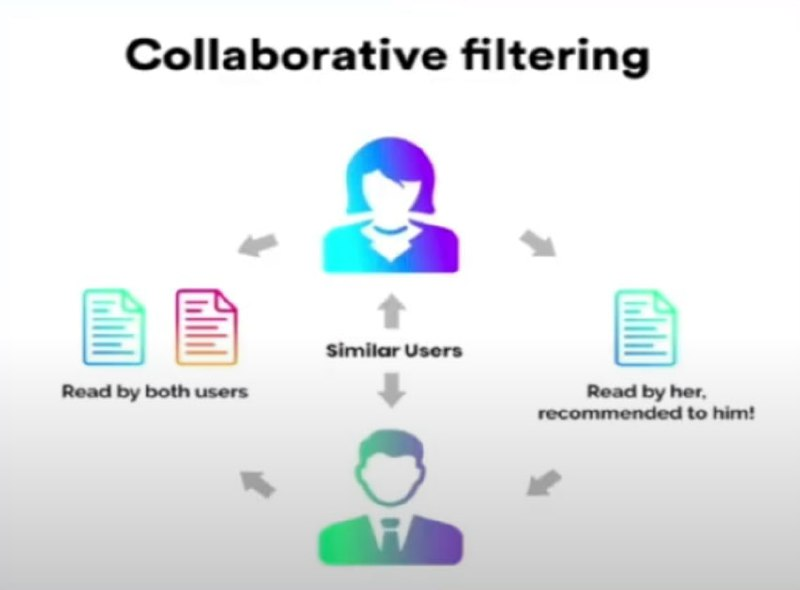

Как можно измерить сходство двух **пользователей**:
- то, какие продукты\услуги они покупают

Как можно измерить сходство между двумя **продуктами\услугами**:
- то, какие пользователи их покупают

**Также подразделяются:**
- user-user collaborative filltering
- item-item collaborative filltering

Также, рекомендательные системы могут быть простыми, например рекомендовать профиль пользователя для принятия управленческих решений


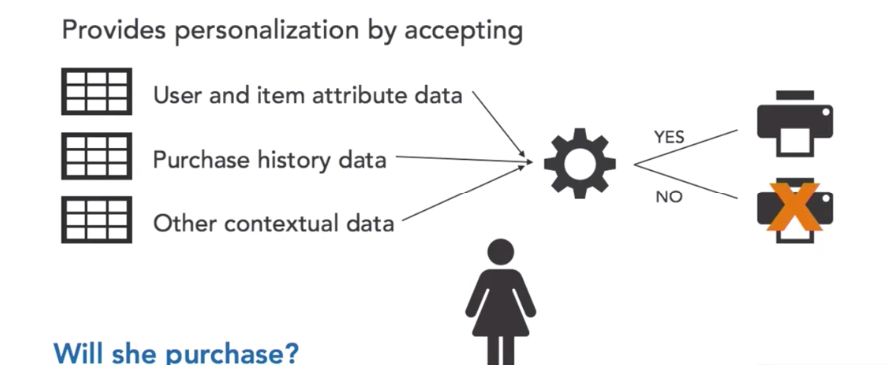

- Основываясь на существующих клиентов и товарных данных, приобретет ли новый клиент страховую сделку или нет?
- Основываясь на истории покупок этого клиента, будет ли он заинтересован в новой покупке?
- Какой из наших существующих клиентов будет заинтересован в нашем новом продукте

Представим, что ты маркетинговый Data Scientist/ML инжинер в банке. Твоя задача решить, какой из существующих клиентов хорошоий канщдидат для программы специального депозита, которую запустил банк. Если клиент хороший кандидат, тогда ты порекомендуешь его для связи и сделки с ним

Сейчас мы будем использовать логистическую регрессию для выбор, какой из клиентов хороший кандидат для сделки, и примет ли определенный клиент предложение или нет. Этого клиента зовут Гоша, он представлен на картинке ниже

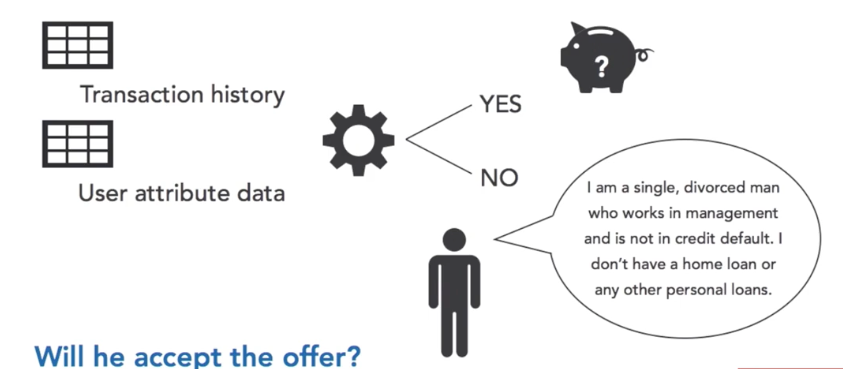

### **Логистическая регрессия как классификатор**

**Логистическая регрессия** *(ЛогР)* - статистическая модель, используемая для прогнозирования вероятности возникновения некоторого события, она выдает ответ в виде числа в промежутке от `0 до 1`. Бинарная ЛогР применяется в случае, когда зависимая переменная является бинарной (может принимать только 2 значения). С помощью ЛогР можно оценивать `вероятность наступления события`

В отличии от обычной регрессии, в методе ЛогР не производится предсказания `значения числовой переменной` исходя из выборки исходных значений. Вместо этого, значением ф-ии является вероятность того, что данное исходное значение `принадлежит к определенному классу`

ЛогР является одним из фундаментальных методов `Машинного Обучения`. ЛогР выполняется быстро и относительное несложно, и ее результаты удобно интерпретировать. По сути, это метод двоичной классификации, но его также можно применять к мультиклассовым задачам

**Логистическая функция** или логистическая кривая - это S-образная кривая *(сигмоидальная кривая)* с уравнением:

$$f(x) = \frac{L}{1+e^{-kx}}$$

где:
- k = коэффициент для переменной x, он отвечает за `логистическую скорость роста`, *крутизна кривой*
- x = это `переменная` функции
- L = это `супремум` значений ф-ии, т.е. максимальное и минимальное значение, если будет 1, то макс. будет 1, если 2 - то 2 и т.д., нижний супремум равен 0, чтобы его изменить, нужно вычесть или прибавить к этой ф-ии определенное число

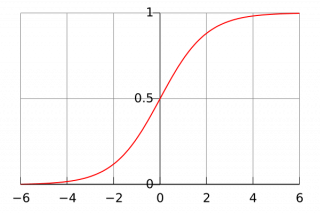

*график логистической кривой (лог. ф-ии)*

ЛогР является моделью, которая основана на `вычислении вероятности`, эта логистическая ф-я выводится через формулу для вычисления вероятности. ЛогР это не применение сигмоидальной ф-ии активации к линейной регрессии, а `вычисление вероятности`

**Формулировка задачи**

Допустим, что у нас есть некоторый `набор данных`, состоящих из элементов вида $x = (x_1, ..., x_m)$, m - число различных признаков, каждый из которых описывает определенную хар-ку `рассматриваемых` `объектов` или `наблюдений`

Hам нужно создать `модель`, основанную на `логистической регрессии`, некоторой зависимой переменной $y$ на множестве независимых переменных $x = (x_1, ..., x_m)$. У нас есть известные входные значения $x_i$, и соответствующее фактическое значение результата $y$ для каждого наблюдения $i = 1, ..., n$, `n - число наблюдений`

Цель - `найти ф-ю логистической регрессии` $P$ такую, `чтобы прогнозируемые ответы` $P(x_i)$ были как можно `ближе к фактическому ответу` $y_i$ для каждого наблюдения $i = 1, ..., n$. Нужно помнить, что фактический ответ может быть только `0 или 1 в задачах двоичной классификации`. Это означает, что каждое значение $P(x_i) должно быть близко к 0 или 1

Если у нас есть ф-я ЛогР $P(x)$, то мы можем использовать её для прогнозирования выходных данных для новых входов, не учавствующих в обучении модели, при условии, что `лежащая в основе математическая зависимость` `не изменилась`

**Подготовка данных**

Условия, которым должны удовлетворять данные, почти такие же, как и для линейной регрессии:
- Наблюдения *(входные данные)* должны быть `независимы друг от друга`
- Между признакам *(независимыми входными переменными)* не должно быть `мультиколлинеарности`
- Зависимая переменная должна иметь `бинарное значение`, т.е. 0 или 1
- Достаточное кол-во обучающих примеров
- В обучающих данных `не` должно быть `много выбросов`

**Масштабирование признаков.** как и в случае с линейной регрессией, для алгоритма логистической регрессии важно, чтобы признаки были приведены к одному масштабу. Для этого используем стандартизацию

Каждый признак представляется относительно общего центра распределения *(для каждого признака центр распределения свой)*:

$$x_{ij} = \frac{x_{ij} - mean(X_j)}{std(X_j)}, i=1,...,n,j=1,...,m$$

$$std(X_j) = \sqrt{\frac{1}{n}\sum_{i=1}^n(x_{ij}-mean(X_j))^2}$$

$$mean(X_j) = \frac{1}{n}\sum_{i=1}^nx_{ij}, X_j = (x_1j,...,x_nj)$$

где:
- $n$ = число наблюдений (объектов)
- $m$ = число признаков
- $X_j$ = список всех значений из набора данных для данного признака (j-я координата вектора)
- $mean$ = среднее значение
- $std$ = стандартное отклонение

In [22]:
test = [1,2,3,4,4]

In [23]:
def mean(X_j = list | np.ndarray) -> float:
    '''Ф-я для вычисления среднего значения'''
    # число наблюдений
    n = len(X_j)

    return sum(X_j) / n

In [24]:
print(mean(test))

2.8


In [25]:
def std(X_j = list | np.ndarray):
    '''Ф-я для вычисления стандартного отклонения'''
    # Число наблюдений
    n = len(X_j)
    # Среднее 
    mean_X_j = mean(X_j)
    # Наблюдения без среднего в квадрате
    wo_mean = [(x-mean_X_j)**2 for x in X_j]

    return (sum(wo_mean) / n)**0.5

    

In [26]:
def data_scale(X_j = list | np.ndarray) -> list:
    '''Ф-я для масштабирования данных'''
    # Среднее арифметическое
    X_mean = mean(X_j)
    
    # Среднеквадратичное отклонение
    X_std = std(X_j)

    return [(x-X_mean) / X_std for x in X_j]



In [27]:
print(data_scale(test))

[-1.5434872662825796, -0.6859943405700353, 0.171498585142509, 1.0289915108550534, 1.0289915108550534]


**Обучение**

В ЛогР вместо среднеквадратичного расстояния, используемого в линейной регресии, испрользуется `ф-я логистической ошибки` или `бинарной кросс-энтропии`. модель оптимизируется по методу максимального правдоподобия, чтобы найти оптимальную область разграничения между классами. Эта ф-я измеряет  разницу между предсказанными вероятностями и фактическими классами. Формула логистической ошибки выглядит следующим образом:

$$L(O,T) = \frac{1}{n}\sum_{i=1}^n - (t_ilog(o_i) - (1-t_i)log(1-o_i))$$

где:
- $O$ = список ответов модели для каждого входного вектора признаков
- $T$ = список целевых значений

Если ответ модели будет равен единице, то в выражении $log(1-o_i)$ будет ошибка, так как `логарифм нуля не определен`. Чтобы предотвратить ошибку, можно просто изменить значение `1 на 0.99` - `логарифм будет определен`. Если ответ будет равен нулю, то ошибка будет в выражении $log(o_i)$, можно изменить 0 на 0.01

Ответ модели:

$$o = \frac{1}{(1+e^{-z})}$$

где:
- $z$ = линейная комбинация входных данных и коэффициентов регрессии
$$z = x_1w_1 + ..., + x_m w_m + b$$

Эта ф-я преобразует любое вещ-е число $z$ в значение между 0 и 1, что `интерпретируется как вероятность`

Производная ф-ии логистической ошибки по весу и смещению:

$$L'_{wi} = x_{ij}(o_i-t_i)\frac{1}{n}, L'_b = (o_i - t_i)\frac{1}{n}$$

Обучение проиcходит методом `стохастического спуска`- изменение весов на каждом примере



**Уменьшение переобучения**

Для улучшения обобщающей способности модели, т.е. уменьшения эфекта переобучения так же, как и для линейной регрессии, рассматривается L1- и L2-регуляризация. Выглядит она почти так же как и для линейной регрессии.

$$L_{2} : L(t_{i},o_{i}) = -(t_{i}log(o_{i}) - (1-t_{i})log(1-o_{i})) + \lambda\sum_{j=1}^mw^2_j$$

где:
- $m$ = число весов
- $\lambda$ = коэффициент регуляризации

Другие доп. члены для целевой ф-ии оптимизации выглядят и применяются при обучении аналогично, как и для `линейной регрессии`

**Оценка качества модели**

Для оценки качества модели при обучении используется `ф-я логистической ошибки`. Она используется в задаче классификации, так как логистическая ф-я ошибки работает со значениями от `0 до 1`, что соответствует значениям логистической ф-ии *(сигмоиды)*

`MSE` для измерения расстояния между ответами и целевыми значениями `использовать некорректно`, т.к. при классификации *(которую решает ЛогР)* мы получаем `значение вероятности`, а не `число` *(как при регрессии)*

Оценить качество обученной модели можно с помощью метрики `accuracy` и `precision`

**Точность (accuracy)** представляет собой долю правильно классифицированных объектов из общего числа объектов в наборе данных *(тестовом)*. Однако, точность может быть обманчива в случае несбалансированных классов, посколько она не учитывает соотношения ложных срабатываний

$$accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

где:
- **TP** - *`true positive`*, т.е. ответ, который классифицирован как `1` и на самом деле должен быть `1`
- **TN** - *`true negative`*, т.е. ответ, который классифицирован как `0`, и на самом деле должен быть `0`
- **FP** - *`false positive`*, т.е. ответ, который классифицирован как `1`, а на самом деле должен быть `0`
- **FN** - *`false negative`*, т.е. ответ, который классифицирован как `0`, а на самом деле должен быть `1`

**Точность (precision)** показывает долю объектов, названных моделью положительными, которые действительно являются положительными. `Эта метрика важна, когда небоходимо минимизировать кол-во ложных положительных результатов`

$$precision = \frac{TP}{TP+FP}$$

**Полнота (recall) или чувствительность** - показывает долю объектов положительного класса, которые были правильно выявлены моделью

$$recall = \frac{TP}{TP+FN}$$

Эти метрики являются фундаментальными для оценки качества модели и производительности бинарной классификации

F1-мера (F1-score) представляет собой среднее гармоническое точности и полноты, что позволяет объединить эти две метрики в одну. Эта метрика полезна, когда точность и полнота имеет одинаковую важность

$$F1 = 2 \cdot \frac{precision \cdot recall}{precision+recall}$$

**Создание набора данных для задачи классификации**

Делаем учебный набор данных с помощью генератора точек

[1.44, 2.21, 2.67, 2.87, 2.11] [1.65, 1.6099999999999999, 1.19, 1.96, 1.1099999999999999]
[5.0600000000000005, 3.9, 1.65, 1.94, 1.98] [1.33, 0.86, 0.98, -0.48, 1.5]


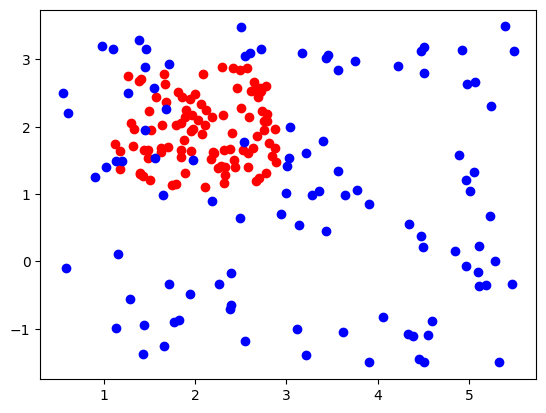

In [28]:
# Импортированиие библиотек
# ---------------------------------------------------------
from random import randint          # Для генерации случайных чисел
import matplotlib.pyplot as plt     # Для визуализации

# Функция
# ---------------------------------------------------------
def data_points(n_samples: int, class_point: tuple, noise: int | float = 1):
    def offset_point():
        # Создаем случайные значения для разности точек в классе
        offset_x = randint(-100 * noise, noise * 100) / 100
        offset_y = randint(-100 * noise, noise * 100) / 100

        # Распределяем точку вокруг классового центра,
        # прибавляя случайные сгенерированные числа к центру класса
        x = class_point[0] + offset_x
        y = class_point[1] + offset_y

        # Возвращаем точку
        return x, y

    # Получаем список точек (кортежей - (x, y))
    points = [offset_point() for _ in range(n_samples)]
    # Разделяем список на список x и y
    x_list = [points[i][0] for i in range(n_samples)]
    y_list = [points[i][1] for i in range(n_samples)]

    # Возвращаем список x, и список y
    return x_list, y_list

# Генерация набора данных
# ---------------------------------------------------------
x1_list, y1_list = data_points(n_samples=100, class_point=(2,2), noise=0.9)
x2_list, y2_list = data_points(n_samples=100, class_point=(3,1), noise=2.5)

# Вывод первых 5 точек
print(x1_list[:5], y1_list[:5])
print(x2_list[:5], y2_list[:5])

# Визуализация
# ---------------------------------------------------------
plt.scatter(x=x1_list, y=y1_list, color='red')
plt.scatter(x=x2_list, y=y2_list, color='blue')
plt.show()

Обозначаем число Эйлера

In [29]:
e = 2.71828182845904523536
e

2.718281828459045

Делаем список точек (векторов признаков)

In [30]:
inputs = [(x1_list[i], y1_list[i]) for i in range(len(x1_list))]
targets = [0 for i in range(len(x1_list))]
# Добавляем второй класс
inputs += [(x2_list[i], y2_list[i]) for i in range(len(x2_list))]
targets += [1 for i in range(len(x2_list))]

Создаем веса и функции, которые будут обрабатывать ответ модели

In [31]:
# Веса модели
weights = [randint(-100,100)/100 for _ in range(3)]
print(weights)

# Ф-я для вычисления z (линейная комбинация входных данных и коэфф. регрессии)
def weighted_z(point):
    z = [item * weights[i] for i, item in enumerate(point)]
    return sum(z) + weights[-1]

# Логистическая функция (ответ модели)
def logistic_func(z):
    return 1 / (1+e**(-z))

[0.47, 0.95, -0.4]


В наборе всего 2 признака *(x, y)*, поэтому создаем только 3 веса *(для каждого признака и для смещения)*. В функциях происходит операция взвешенной суммы для получения `z` и получение `значения логистической функции от z`

Далее, создаем функцию для расчета логистической функции ошибки для всего набора данных. Используется формула лог. ошибки для каждой пары ответа и целевого значения *(логарифм нуля не определен, поэтому добавляем доп значения)*

In [32]:
from math import log

In [33]:
def logistic_error():
    errors = []

    for i, point in enumerate(inputs):
        z = weighted_z(point)
        output = logistic_func(z)
        target = targets[i]

        # Обработка исключений, тк логарифм 0 не определен
        if output == 1:
            output == 0.999999
        if output == 0:
            output == 0.000001
        
        error = -(target * log(output, e) - (1 - target) * log(1 - output, e))
        errors.append(error)

    return sum(errors) / len(errors)

Делаем процедуру обучения весов на всем наборе данных

In [34]:
lr = 0.01

for epoch in range(100):
    for i, point in enumerate(inputs):
        z = weighted_z(point)
        output = logistic_func(z)
        target = targets[i]

        for j in range(len(weights) - 1):
            weights[j] -= lr * (output - target) * (1 / len(inputs))
        
    print(f'epoch: {epoch} | error: {logistic_error():.6f}')
print(weights)

epoch: 0 | error: -1.136052
epoch: 1 | error: -1.128562
epoch: 2 | error: -1.121095
epoch: 3 | error: -1.113652
epoch: 4 | error: -1.106233
epoch: 5 | error: -1.098838
epoch: 6 | error: -1.091468
epoch: 7 | error: -1.084121
epoch: 8 | error: -1.076799
epoch: 9 | error: -1.069502
epoch: 10 | error: -1.062230
epoch: 11 | error: -1.054983
epoch: 12 | error: -1.047761
epoch: 13 | error: -1.040564
epoch: 14 | error: -1.033393
epoch: 15 | error: -1.026248
epoch: 16 | error: -1.019128
epoch: 17 | error: -1.012035
epoch: 18 | error: -1.004967
epoch: 19 | error: -0.997926
epoch: 20 | error: -0.990911
epoch: 21 | error: -0.983923
epoch: 22 | error: -0.976962
epoch: 23 | error: -0.970027
epoch: 24 | error: -0.963120
epoch: 25 | error: -0.956239
epoch: 26 | error: -0.949386
epoch: 27 | error: -0.942560
epoch: 28 | error: -0.935762
epoch: 29 | error: -0.928992
epoch: 30 | error: -0.922249
epoch: 31 | error: -0.915534
epoch: 32 | error: -0.908848
epoch: 33 | error: -0.902189
epoch: 34 | error: -0.89

Я реализовал ЛогР в отдельном файле, импортирую ее оттуда

In [35]:
from tools.logR import LogisticRegression

In [36]:
model = LogisticRegression(inputs, targets, 100, 0.01)
print(model.m)

3


In [37]:
import numpy as np
import pandas as pd

from pandas import Series, DataFrame

import warnings
warnings.filterwarnings('ignore')

Маркетинговый датасет банка открыт для всех и доступен для загрузки в [UCI Machine Learning Repository](https://www.google.com/url?q=https%3A%2F%2Farchive.ics.uci.edu%2Fml%2Fdatasets%2FBank%2BMarketing%23)

In [38]:
bank_full = pd.read_csv('bank-full.csv', sep=';')
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [39]:
bank_full['poutcome']

0        unknown
1        unknown
2        unknown
3        unknown
4        unknown
          ...   
45206    unknown
45207    unknown
45208    success
45209    unknown
45210      other
Name: poutcome, Length: 45211, dtype: object

In [40]:
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [41]:
class LabelEncoder:
    def __init__(self):
        self.classes_ = {}

    def fit(self, data):
        unique_classes = sorted(set(data))
        self.classes_ = {label: idx for idx, label in enumerate(unique_classes)}

    def transform(self, data):
        return [self.classes_[label] for label in data]

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        inv_map = {v: k for k, v in self.classes_.items()}
        return [inv_map[idx] for idx in data]


In [42]:
le = LabelEncoder()

In [43]:
bank_full = bank_full.apply(le.fit_transform)
bank_full[bank_full['y'] == 1]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,41,0,1,1,0,3223,1,0,2,4,8,1038,0,0,0,3,1
86,38,0,1,1,0,961,0,0,2,4,8,1359,0,0,0,3,1
87,23,9,1,1,0,2186,1,0,2,4,8,1313,0,0,0,3,1
129,37,7,1,1,0,3344,1,0,2,4,8,579,0,0,0,3,1
168,36,0,1,2,0,1100,0,0,2,4,8,673,1,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45204,55,5,1,1,0,3678,0,0,0,16,9,300,0,37,8,0,1
45205,7,9,2,1,0,1421,0,1,0,16,9,386,1,0,0,3,1
45206,33,9,1,2,0,1741,0,0,0,16,9,975,2,0,0,3,1
45207,53,5,0,0,0,2639,0,0,0,16,9,456,1,0,0,3,1


In [44]:
bank_full.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [45]:
new_bank_full = bank_full.loc[:, :'poutcome']
new_bank_full

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,40,4,1,2,0,3036,1,0,2,4,8,261,0,0,0,3
1,26,9,2,1,0,945,1,0,2,4,8,151,0,0,0,3
2,15,2,1,1,0,918,1,1,2,4,8,76,0,0,0,3
3,29,1,1,3,0,2420,1,0,2,4,8,92,0,0,0,3
4,15,11,2,3,0,917,0,0,2,4,8,198,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,33,9,1,2,0,1741,0,0,0,16,9,975,2,0,0,3
45207,53,5,0,0,0,2639,0,0,0,16,9,456,1,0,0,3
45208,54,5,1,1,0,5455,0,0,0,16,9,1116,4,181,3,2
45209,39,1,1,1,0,1584,0,0,1,16,9,508,3,0,0,3


In [46]:
bank_full['y']

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [47]:
for col in new_bank_full.columns:
    new_bank_full[col] = data_scale(new_bank_full[col].tolist())

In [48]:
new_bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1.607094,-0.103820,-0.275762,1.036362,-0.13549,0.732955,0.893915,-0.436803,1.514306,-1.298476,0.823773,0.023623,-0.57297,-0.414317,-0.305354,0.444898
1,0.288564,1.424008,1.368372,-0.300556,-0.13549,-0.695795,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.435364,-0.57297,-0.414317,-0.305354,0.444898
2,-0.747423,-0.714951,-0.275762,-0.300556,-0.13549,-0.714243,0.893915,2.289359,1.514306,-1.298476,0.823773,-0.748309,-0.57297,-0.414317,-0.305354,0.444898
3,0.571107,-1.020516,-0.275762,2.373280,-0.13549,0.312051,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.681548,-0.57297,-0.414317,-0.305354,0.444898
4,-0.747423,2.035139,1.368372,2.373280,-0.13549,-0.714927,-1.118674,-0.436803,1.514306,-1.298476,0.823773,-0.239251,-0.57297,-0.414317,-0.305354,0.444898


In [49]:
X = list(new_bank_full.itertuples(index=False, name=None))
y=bank_full['y'].tolist()                 

In [50]:
y[:5]

[0, 0, 0, 0, 0]

In [51]:
X[:5]

[(1.6070942787938665,
  -0.10381968320036279,
  -0.2757617768439383,
  1.0363618194198814,
  -0.13548988776117357,
  0.7329552621509688,
  0.8939154094498307,
  -0.4368034698973588,
  1.5143061054062206,
  -1.2984763315738768,
  0.8237733624632545,
  0.02362321951589019,
  -0.5729698307719466,
  -0.4143174649546546,
  -0.30535358307591304,
  0.44489814000547984),
 (0.2885644540422949,
  1.424007833618724,
  1.3683719028199544,
  -0.3005558687643358,
  -0.13548988776117357,
  -0.6957947379358745,
  0.8939154094498307,
  -0.4368034698973588,
  1.5143061054062206,
  -1.2984763315738768,
  0.8237733624632545,
  -0.4353637845261962,
  -0.5729698307719466,
  -0.4143174649546546,
  -0.30535358307591304,
  0.44489814000547984),
 (-0.7474232654053685,
  -0.7149506899279975,
  -0.2757617768439383,
  -0.3005558687643358,
  -0.13548988776117357,
  -0.7142434466887894,
  0.8939154094498307,
  2.2893591029255966,
  1.5143061054062206,
  -1.2984763315738768,
  0.8237733624632545,
  -0.748309469100346

In [52]:
model = LogisticRegression(X, y, epochs=100)
model.train()

Training Progress: 100%|██████████| 100/100 [00:55<00:00,  1.81epoch/s, epoch=99, error=0.5117, accuracy=0.906, precision=0.433, recall=0.643, f1 score=0.518]

Финальные веса: [0.0632907955321736, -0.026347156926441205, 0.09631057053695435, 0.09850799194804111, -0.09248928828852748, -0.1396261934081422, -0.044345203323839635, -0.13808543411522978, -1.0356179922290365, 0.0758650400799576, -0.09097046757087583, 0.9430382850433109, -0.5828814272153494, 0.25042441662593995, 0.026889228367976234, 0.7176534467509281, -0.7993027558268853]


In [53]:
ID = 83
test = list(X[ID])
answer = y[ID]
print(f'test X: {test}')
print(f'true answer: {answer}')

test X: [1.701274980561836, -1.3260816966556324, -0.2757617768439383, -0.3005558687643358, -0.13548988776117357, 0.8607296524026378, 0.8939154094498307, -0.4368034698973588, 1.5143061054062206, -1.2984763315738768, 0.8237733624632545, 3.2657405117040823, -0.5729698307719466, -0.4143174649546546, -0.30535358307591304, 0.44489814000547984]
true answer: 1


In [54]:
model.predict(test)

0.7463972766988679

## PCA decomposion

[[ 1.          2.          3.          4.          5.          6.
   7.          8.          9.         10.        ]
 [ 0.29516515  0.36423561  6.9423213   5.91647048 12.434902    8.64406194
  16.03086956 16.65725451 21.02763499 19.99365095]]


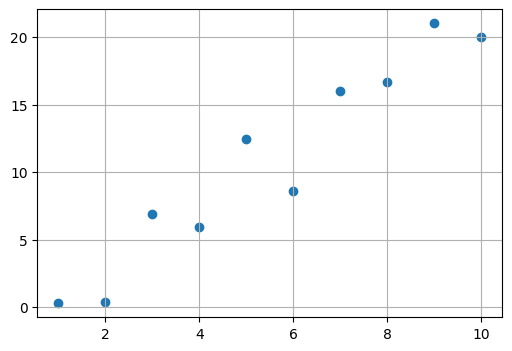

In [70]:
x = np.arange(1,11)
y = 2 * x + np.random.randn(10)*2
X = np.vstack((x,y))
print(X)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.grid(True)
plt.show()

**Отцентрируем выборку** *(линейно сдвинем ее, чтобы средние значения признаков равнялись 0)*

(array([-4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5]), array([-10.5354915 , -10.46642104,  -3.88833535,  -4.91418617,
         1.60424535,  -2.18659471,   5.20021292,   5.82659786,
        10.19697834,   9.1629943 ]))
Mean vector: (np.float64(5.5), np.float64(10.830656648698456))


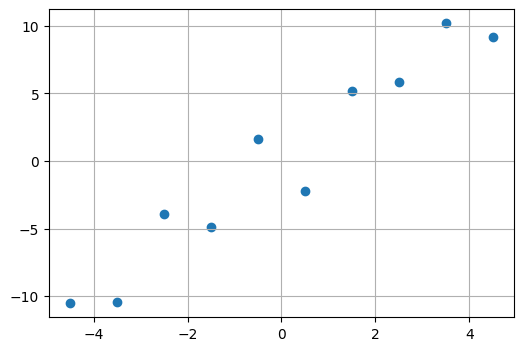

In [71]:
Xcentered = (X[0] - mean(x), X[1] - mean(y))
m = (mean(x), mean(y))
print(Xcentered)
print(f'Mean vector: {m}')

plt.figure(figsize=(6,4))
plt.scatter(Xcentered[0], Xcentered[1])
plt.grid(True)
plt.show()

**Ковариационная матрица**

Для описания формы случайного вектора, необходима **ковариационная матрица**

Это матрица, у которой (i, j)-элемент является корреляцией признаков ($X_i$, $X_j$). Формула ковариации:

$$Cov(X_i,X_j) = E [(X_i - E(X_i)) \cdot (X_j- E(X_j))] = E(X_i, X_j) - E(X_i) \cdot E(X_j)$$

В нашем случае она упрощается, так как $E(X_i) = E(X_j) = 0$:

$$Cov(X_i, X_j) = E(X_i, X_j)$$

Заметим, что когда $X_i = X_j$:
$$Cov(X_i, X_j) = Var(X_i)$$

> **Замечание:** Ковариационная матрица является обобщением дисперсии на случай многомерных случайных величин - она так же описывает форму (разброс) случайной величины, как и дисперсия

И это справедливо для любых величин

In [84]:
def cov(x: list, y: list) -> float:
    '''Функция для вычисления ковариации'''
    x_mean = mean(x)
    y_mean = mean(y)

    cov = sum([(xi - x_mean)*(yi - y_mean) for xi, yi in zip(x, y)]) / len(x)-1
    return cov

In [79]:
cov(Xcentered[0], Xcentered[1])

np.float64(19.852859552664082)

In [80]:
# Тест 1: Положительная ковариация
assert cov([1, 2, 3], [2, 4, 6]) > 0

# Тест 2: Отрицательная ковариация
assert cov([1, 2, 3], [6, 4, 2]) < 0

# Тест 3: Нулевая ковариация (примерно)
assert abs(cov([1, 2, 3], [2, 2, 2])) < 1e-10

In [ ]:
covmat = np.cov(Xcentered)
print(covmat, '\n')
print(f'Variance of X: {np.cov(Xcentered)[0,0]}')
print(f'Variance of Y: {np.cov(Xcentered)[1,1]}')
print(f'Covariance X and Y: {np.cov(Xcentered)[0,1]}')

[[ 8.25       19.85285955]
 [19.85285955 51.60960162]] 

Variance of X: 9.166666666666666
Variance of Y: 57.34400180453388
Covariance X and Y: 22.058732836293423


In [73]:
model.visualize_predicts()

ModuleNotFoundError: No module named 'sklearn'

**Оценка рекомендательных систем** *(evaluation of recommendational systems)*

Можно использовать метрики `Классификации` и `Регрессии` для оценки рекомендательных систем

1. RMSE
2. MAE
3. Accuracy
4. ROC/AUC
5. Precision
6. Recall